# **Summary of Exploration**

In [10]:
# Import required libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import pandas as pd

## **Automatic Validation Exploration Summary**

**Please first see probe_autoval_rocauc_final.ipynb for the explanation of my automatic validation metric.** 

For my exploration of what metric worked best (what worked, what didn't), see below. 

Note, the old probe autoval scripts can be founded in the probe_autoval_legacy folder (they are mostly not very useful though...)

### **Initial Metric**
For my initial metric, I calculated individual token activation validations for each token using the following method: 
activation validation = activation of token x absolute semantic similarity of the group the token is in   

I have chosen to use the group as for the vast majority of the examples, the activation occurs in the . or , at the end of the phrase.     
However, this activation represents the **concept of the group of tokens just before the . or ,.**  
The activation validation scores of all the tokens are then **summed** across the text to the produce the **overall score** for the text.    
As an indication of **overall performance**, the **difference** between the activation validation of the example.txt and the unrelated.txt is also given as a result.

In [ ]:
# Initial activation validation score calculation
def compute_activation_validation_score(token_strs, scores, concept_text):
    """
    Sums the activation-validation scores for the whole text.
    Each token's contribution is: activation * abs(similarity of its group).
    The function groups tokens by separators and then sums the contributions.
    """
    total = 0.0
    current_group_tokens = []
    current_group_scores = []
    # Loop through tokens and accumulate group data
    for i, (token, score) in enumerate(zip(token_strs, scores)):
        current_group_tokens.append(token)
        current_group_scores.append(score)
        # when a separator is reached, finalise the group
        if is_group_separator(token_strs, i):
            group_string = "".join(current_group_tokens).strip()
            similarity = compute_semantic_similarity(group_string, concept_text)
            total += sum(sc * abs(similarity) for sc in current_group_scores)
            # Reset group lists for the next group
            current_group_tokens = []
            current_group_scores = []
    # Process any remaining tokens not ending with a seperator
    if current_group_tokens:
        group_string = "".join(current_group_tokens).strip()
        similarity = compute_semantic_similarity(group_string, concept_text)
        total += sum(sc * abs(similarity) for sc in current_group_scores)
    return total

### **Why did this not work?**
At the beginning, I thought that this metric was good as I tested it on the original probes.   
These probes had good accuracy and specificity already and were **barely activating on the unrelated texts**.   
-	However, after looking at probes that had a **lot of activations for the unrelated texts**, I realised the metric was not actually good
-	The **low semantic similarity** for the unrelated text activations downplayed a lot of the wrong activations
-   The metric was making the probe **seem a lot better than it actually was**

For example, say there were **10 wrong activations** in the unrelated txt, where the **activation was 1.**   
Technically, these should result in a big penalty and result in punishment for the metric.   
However, since the **semantic similarity would be so low (as the phrases are unrelated)**, e.g. like 0.02, the punishment to the overall score would only be 1 x 0.02 = 0.02, which is a **very small punishment for a wrong activation.**       

Thus, I decided that this metric was **not good enough.**

### **Trying Other Methods**
After realising the method was bad I did some research into other metrics I could use.    
I came across the pearson correlation.   
The Pearson correlation coefficient (r) measures the strength and direction of the linear relationship between two continuous variables.   
I originally though this would work as I wanted a metric evaluate the probe based on a good probe having:    
High activation when semantic similarity is high    
Low activation when semantic similarity is low     

However, after validating this method and validating a few of the probes using the coefficient I found that the Pearson correlation was not a good metric because:   
- It relied on the semantic similarity and activation scores being closely related, not just in direction   
- So, it would penalise instances where the probe activation was high and the similarity was medium, or vice versa, because it didn't fit the correlation    
- Thus, it was too harsh and the metric was not very reliable    

So, from this, I knew I wanted a metric that was not strictly correlation based as it did not suit the purpose. 

In [ ]:
# Pearson correlation calculation
def compute_activation_validation_score(token_strs, scores, concept_text):
    """
    Instead of summing activation*similarity, we compute a Pearson correlation
    between activation and similarity across all tokens (grouped by punctuation).
    
    Returns:
        float: The Pearson correlation (r) between each token's activation
               and its group's semantic similarity.
               If fewer than 2 tokens exist, returns 0.0 (arbitrary fallback).
    """
    # store activation and similarity for each token
    all_activations = []
    all_similarities = []
    
    current_group_tokens = []
    current_group_scores = []

    for i, (token, score) in enumerate(zip(token_strs, scores)):
        current_group_tokens.append(token)
        current_group_scores.append(score)
        
        # finalize the group when a separator is reached
        if is_group_separator(token_strs, i):
            group_string = "".join(current_group_tokens).strip()
            similarity = compute_semantic_similarity(group_string, concept_text)
            
            # for each token in this group, activation is 'score',
            # similarity is 'similarity' (same for all tokens in the group).
            for sc in current_group_scores:
                all_activations.append(sc)
                all_similarities.append(similarity)
            
            # Reset group lists
            current_group_tokens = []
            current_group_scores = []
    
    # Process any remaining tokens not ended by a separator
    if current_group_tokens:
        group_string = "".join(current_group_tokens).strip()
        similarity = compute_semantic_similarity(group_string, concept_text)
        
        for sc in current_group_scores:
            all_activations.append(sc)
            all_similarities.append(similarity)
    
    # Compute pearson correlation over all tokens
    if len(all_activations) < 2:
        # Not enough points to compute correlation
        return 0.0
    
    r_value, p_value = pearsonr(all_activations, all_similarities)
    return r_value

### **Final automatic validation**
For explanations of the final metric I decided upon, see separate final notebook --> prove_autoval_rocauc_final.ipynb

## **Creating a Hold-Out Test Set for Validation Summary**
### **My approach**
- Wanted to create some texts similar to the examples given - similar structure, extra validations
- Wanted to create example texts with more variety - medical texts, different structures, realistic still
- Wanted to create unrelated texts with more variety - focus on more than one person, colloqial vs formal, different topics, test the robustness of the concept detection   

Note: Can find simple explainations of each text in inputs/example_unrelated_description.txt   
This is for ease of use when evaluating using the automatic validation metric    
Contains information such as:   
- Structure of the text   
- Source of text   
- Is the text single-person focused? 
- What type of text - for unrelated    
- Other details: numbers, vocab, colloqial?


### **Example texts**
For **example2**, I prompted ChatGPT (o1) to generate a **similar, but different validation example**. I used the following prompt below:

*I am trying to generate validation text examples for some probes which detect medical specific concepts.     
The texts should be around 300 – 450 words in length. 
The texts should include clinical concepts as they would appear in physician notes, radiology reports, and medical diagnoses. Examples should use medical terminology and focus on clinical presentations, diagnostic findings, and treatment considerations*     

*An example is shown below...*    

*Please produce a different example text to the one above, that still stays within my requirements. The text can be structured differently, but needs to mimic a normal medical text.*    

*It is extremely vital that everything mentioned in the text is medically possible and that the text makes sense as a whole. The symptoms, medical histories, and laboratory results must all be viable, and the patient should present with a realistic set of conditions.*     

*The example text should include the following concepts, but in varying degrees. These concepts do not need to be fully named, however the concept itself should be clearly embedded within the example.*

*The concepts are listed below...*   

For **example3**, I used the same prompt, but asked to generate in a **clinical report style**.   

For **example4**, I wanted to look at including only **specific concepts**, to test if the probes behaved as expected. I wanted to make sure the probes were activating for specific concepts, not just medical text...    
*Can you give me a text, structured like the example I gave you, that only focuses on the following concepts (as well as other relating concepts): "hypothyroidism" "heavy alcohol use", "pregnancy”*

For **example5, 6**, I took from **online case studies or textbooks**.   
Sources: http://repository.stikesrspadgs.ac.id/71/1/100%20Case%20Studies%20in%20Pathophysiology-532hlm%20%28warna%20hanya%20cover%29.pdf, https://pmc.ncbi.nlm.nih.gov/articles/PMC7120678/   

### **Unrelated texts**
For **unrelated2**, I used o1 generation:
*Can you now create an unrelated text example. I would like the vague structure to mimic the structure of the example, in order to create a fair test. For the unrelated text example, do not mention or reference any of the concepts from the list before. The text should not be of the medical domain. An example unrelated text is shown below...*

I specified that I wanted an output with **numbers/symbols**:
- Found they were often activated on by the probes
- Similar to medical texts - often have lots of numbers too
- Use to validate probe specificity     

**unrelated3.txt**: **Colloquial** text from Reddit post, **mis-spellings and lack of punctuation, first-person** 

**unrelated4.txt**: Character analysis of fictional character, **single-person focused, many names, rare vocab**, literature focused    

**unrelated5.txt**: **Scientific explanation of alcohol**, chosen to validate if "heavy alcohol use" probe is **word dependent or context dependent**    

*"Sugar alcohols are alcohols that are made by hydrogenating sugar molecules. Hydrogenation basically means "sticking more hydrogen atoms onto it". Sugar alcohols are quite different from the types of alcohol that ethanol belongs to. For one thing, they are solid at room temperature (like sugar is). Also, you can't produce sugar alcohols through fermentation..."*

**unrelated6.txt**: **Academic review** article on corporate law, includes citations    

unrelated7.txt: Wikipedia article of famous person, single-person focused, currently not in use for validation   

### **Notes**   
To see the actual full example texts, please see the inputs folder.    
I also have the sources in more detail if you need in my own documents.   
I have added these new texts to the final auto-val notebook. It does make the output pretty long, but there is a summarised results output for brevity.   
It is useful to still manually look at the results though, so it may be useful to still scroll through. 




### **Interesting for Alcohol Auto-Val**

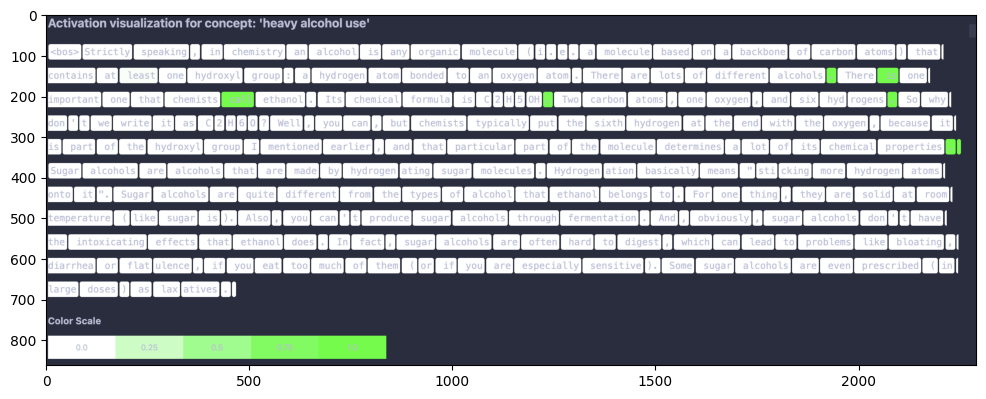

In [7]:
# Probe (0.8) for example
image_path = "alcohol_autoval.png"  # Change this to your image file path
img = mpimg.imread(image_path)

plt.figure(figsize=(12,12))  # Adjust the figure size
plt.imshow(img)

## **Removing Bad Mined Negatives**

Whilst I was checked the mined negatives, I found that a few had some of the medical concepts embedded within. 

**The examples I removed were:**     
1: "<bos>During my pregnancy, I tried to gather as much information on how painful labor might actually be. I would often hear \u201cmine was horrible, but everyone\u2019s pregnancy is different\u201d or \u201cit was the worst pain I\u2019ve ever felt in my life!\u201d\n\nI heard many horror stories which often ended with, \u201cwell, don\u2019t worry. You\u2019ll forget about the pain as soon as your child is born.\u201d Not the most reassuring for a first-time mother, but something I definitely kept in mind the entire time.\n\nI had feared the unknown, but on the other hand, I knew there was no turning back and that my baby was coming one way or another!\n\nTwo weeks before my due date, I noticed some blood. My water didn\u2019t break and I saw no mucous plug, but it seemed that something was happening earlier than expected. Soon after, at 1 a.m. I woke up from a notably different type of cramping. It began to occur every 5 minutes. It wasn\u2019t that painful (yet), but uncomfortable. I felt as if I had to go diarrhea every five minutes. If this is labor, I could handle it for sure I thought, but I knew this was only the beginning."     

2: "<bos>Enhanced absorption and inhibited metabolism of emodin by 2, 3, 5, 4'-tetrahydroxystilbene-2-O-\u03b2-D-glucopyranoside: Possible mechanisms for Polygoni Multiflori Radix-induced liver injury.\nPolygoni Multiflori Radix (PMR) has been commonly used as a tonic in China for centuries. However, PMR-associated hepatotoxicity is becoming a safety issue. In our previous in vivo study, an interaction between stilbenes and anthraquinones has been discovered and a hypothesis is proposed that the interaction between stilbene glucoside-enriching fraction and emodin may contribute to the side effects of PMR. To further support our previous in vivo results in rats, the present in vitro study was designed to evaluate the effects of 2, 3, 5, 4'-tetrahydroxystilbene-2-O-\u03b2-D-glucopyranoside (TSG) on the cellular absorption and human liver microsome metabolism of emodin. The obtained results indicated that the absorption of emodin in Caco-2 cells was enhanced and the metabolism of emodin in human liver microsomes was inhibited after TSG treatment. The",    

3: "<bos>Autosomal dominant polycystic kidney disease (ADPKD) is a common monoallelic disorder associated with progressive cyst development and resulting in end stage renal failure (ESRD) in 50% of patients by 60y. However, there is considerable phenotypic variability, extending from in utero onset to patients with adequate renal function into old age. Autosomal dominant polycystic liver disease (ADPLD), as traditionally defined, results in PLD with minimal renal cysts. Classically there have been considered two ADPKD genes, PKD1 and PKD2, encoding PC1 and PC2, and two ADPLD genes, PRKCSH and SEC63, but in the past few years greater genetic heterogeneity has been described, with nine genes now implicated overall. Recent data also indicates an overlap in etiology and pathogenesis associated with ADPKD and ADPLD, with the efficient biogenesis and localization of the PC-complex central to both disorders. During the last funding period we identified a novel gene, GANAB, which is associated with both disorders, where the encoded protein, GII?? is involved in the maturation and trafficking of PC1. In this proposal we will take advantage of advances in next generation sequencing (NGS) methodologies",     

Note, 1 and 2 actually **both appeared twice** in mined negatives.   
The concepts that are embedded in these are: pregnancy, acute liver disease, elevated liver enzymes. 

As an initial experiment, I removed the examples and looked at the performance metrics.   
Overall, the performance metrics did not change by a lot (as expected), but there were some small changes.   
The scores for pregnancy changed the most - there was a noticeable increase in the performance metrics.   
The scores for elevated liver enzymes and acute liver disease also increased (for all performance metrics), but by less (also as expected).   
The rest of the scores all either increased or decreased, but on a smaller scale - like within +/- 0.005.   

**The slight changes for the pregnancy metrics are shown below in the plot.**



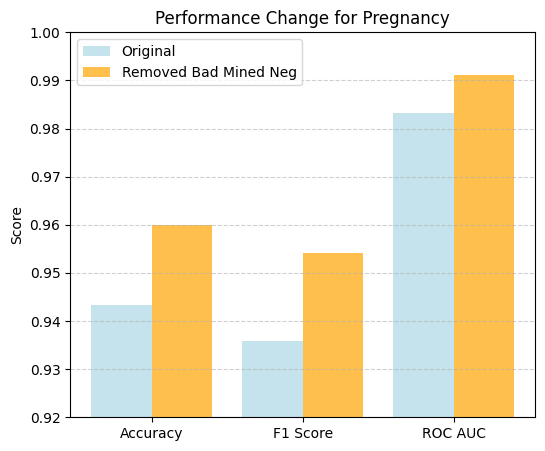

In [5]:
# Categories
metrics = ["Accuracy", "F1 Score", "ROC AUC"]

# Data for "Removed Bad Mined Neg"
removed_bad_neg_means = [0.96, 0.9541, 0.9912]

# Data for "Original"
original_means = [0.9433, 0.9358, 0.9833]

# Bar width
bar_width = 0.4  
x = np.arange(len(metrics))  

# Create figure
plt.figure(figsize=(6, 5))
plt.bar(x - bar_width/2, original_means, bar_width, label="Original", color="lightblue", alpha=0.7)
plt.bar(x + bar_width/2, removed_bad_neg_means, bar_width, label="Removed Bad Mined Neg", color="orange", alpha=0.7)

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Change for Pregnancy")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Zoom in by adjusting the y-axis limits to emphasize changes
plt.ylim(0.92, 1.0)

# Show plot
plt.show()

## **Period Proportion for Examples (Positive/Negative)**
The current probes are being trained on the last token for each of the input texts.    

This is good as it captures the concept quite well, but also bad as we're seeing it activate a little bit too much on punctuation as we're only training on positive examples that end in '.'.         

So, I wanted to improve the positive examples a little and do some simple modifications to see what ramifications it might have.   

Instead of first changing the model training process, I wanted to run a more simple and direct set of experiments first - removing the periods at the end of the generated pos/neg examples.    

To do this, I trained the model on the same examples, but I removed different proportions of periods (full-stops) at the ends of the generated pos/neg examples that were specific to the concept.    

I validated using the cross-validation performance metrics and then also using my new auto-val metric.   

**Note**     
Due to time constraints and also to save some resources, I just tested these experiments on 4 of the concepts for now. I tried to strategically pick a variety of concepts that provided a good overview.   
I also tried to choose concepts that were represented strongly and more weakly in the example/unrelated test sets.     
I also tried taking away the periods on the general negative examples - but that also led to decreased performance metrics. 
**Something to explore though more!**



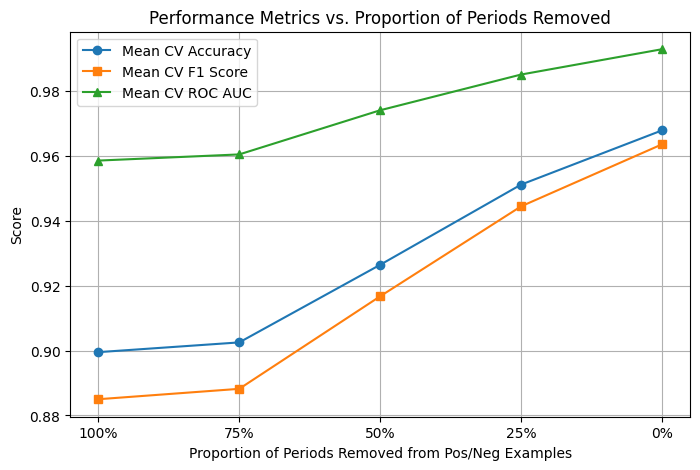

In [2]:
# Data
proportions_removed = [1.00, 0.75, 0.50, 0.25, 0.00]
mean_cv_accuracy = [0.8995, 0.9025, 0.9264, 0.9511, 0.9678]
mean_cv_f1 = [0.8850, 0.8882, 0.9167, 0.9444, 0.9635]
mean_cv_roc_auc = [0.9585, 0.9604, 0.9740, 0.9850, 0.9928]

# Convert proportions to percentage labels
x_labels = ["100%", "75%", "50%", "25%", "0%"]

# Create plot
plt.figure(figsize=(8, 5))
plt.plot(x_labels, mean_cv_accuracy, marker='o', label='Mean CV Accuracy')
plt.plot(x_labels, mean_cv_f1, marker='s', label='Mean CV F1 Score')
plt.plot(x_labels, mean_cv_roc_auc, marker='^', label='Mean CV ROC AUC')

# Labels and title
plt.xlabel("Proportion of Periods Removed from Pos/Neg Examples")
plt.ylabel("Score")
plt.title("Performance Metrics vs. Proportion of Periods Removed")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

### **Performance Metrics**
As you can see, increasing the proportion of periods removed caused a decrease in all the performance metrics.    
I am not entirely sure why this, but some possible reasons could be:    
- The period provides the model a 'signal' of some sorts --> allows the packaging of the concepts, and gives the probe a good checkpoint
- Removing the period damaged the sentence structure --> caused the probe to not be trained on correct sentences

From this, we can see that it is beneficial for the performance of the probe to keep the periods in for the last token. We should explore other options though:   
- Randomly truncating the last sentence
- Making the prompts longer - so that the first few sentences have periods   
- Randomly sampling from longer texts   
- Training the probe on more than one token   

For training the probe on more than one token we could:   
- Randomly sample - e.g. one token per 10 tokens    
- Have longer examples - sample the last token from each sentence   

### **Visualisation on Validation Text** ###
Below, is a visualisation of the probe on the example text.   
(This is from the probes trained on examples with 0.80 of the periods removed.)   
As you can see, there are a lot more activations on non-punctuation, and also a lot more activation in general.   
I have included the original below as comparison (no periods removed).

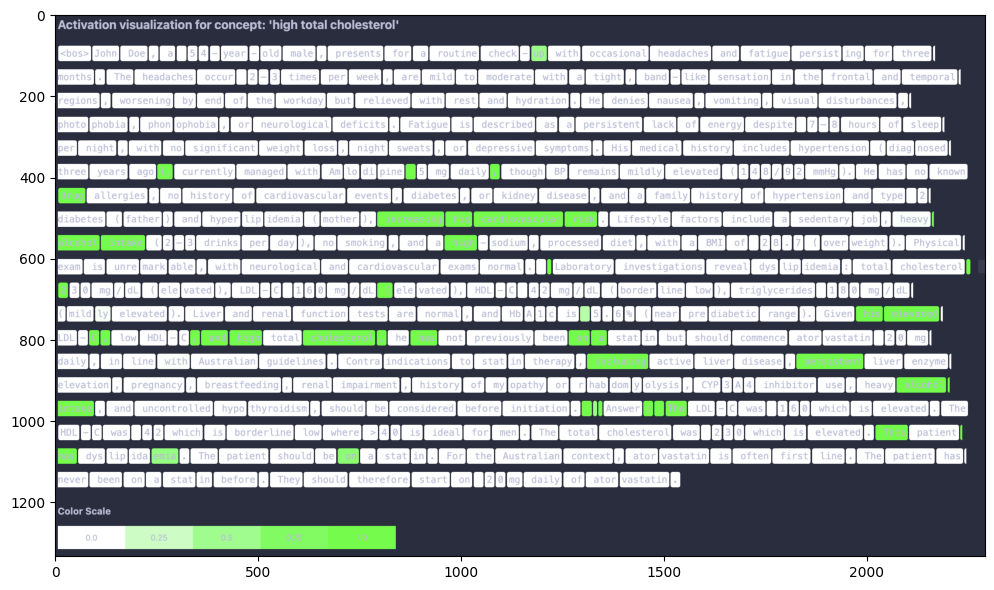

In [3]:
# Probe (0.8) for example
image_path = "probe_08_example.png"  # Change this to your image file path
img = mpimg.imread(image_path)

plt.figure(figsize=(12,12))  # Adjust the figure size
plt.imshow(img)

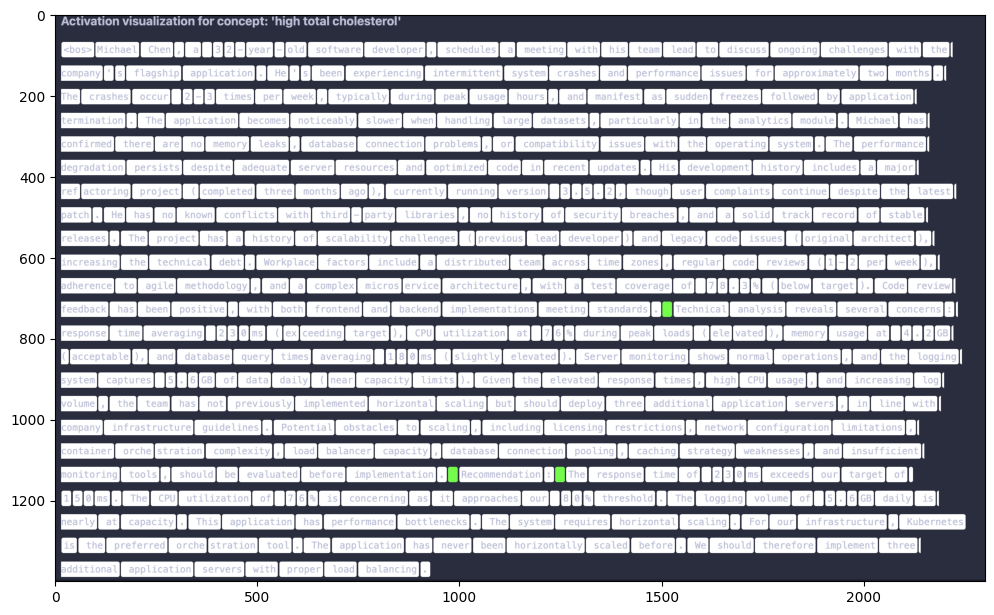

In [4]:
# Probe (0.8) for unrelated
image_path = "probe_08_unrelated.png"  # Change this to your image file path
img = mpimg.imread(image_path)

plt.figure(figsize=(12,12))  # Adjust the figure size
plt.imshow(img)

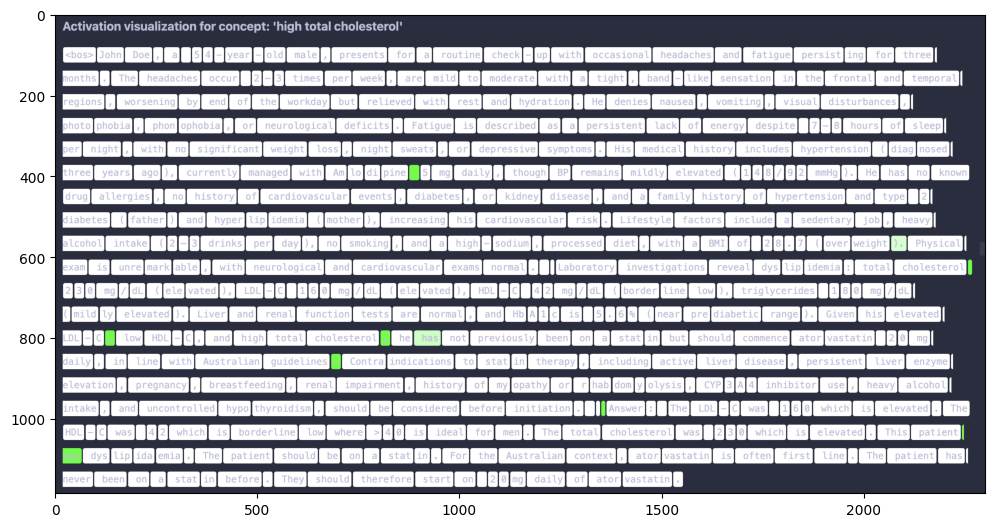

In [5]:
# Probe (original - 0) for unrelated
image_path = "probe_original_example.png"  # Change this to your image file path
img = mpimg.imread(image_path)

plt.figure(figsize=(12,12))  # Adjust the figure size
plt.imshow(img)

### **New Auto-Val Metrics**

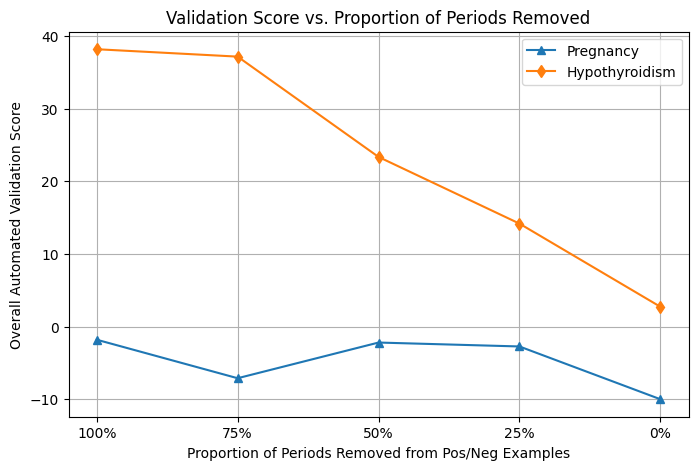

In [6]:
import matplotlib.pyplot as plt

# Data
proportions_removed = ["100%", "75%", "50%", "25%", "0%"]
high_total_cholesterol = [-27.379, -0.45037, 4.4920, -3.8396, -1.8995]
dyslipidemia = [104.076, 95.941, 73.983, 109.514, 55.538]
pregnancy = [-1.8044, -7.1040, -2.1943, -2.7331, -9.9936]
hypothyroidism = [38.171, 37.1527, 23.349, 14.1746, 2.7309]

# Create plot
plt.figure(figsize=(8, 5))
plt.plot(proportions_removed, pregnancy, marker='^', label='Pregnancy')
plt.plot(proportions_removed, hypothyroidism, marker='d', label='Hypothyroidism')

# Labels and title
plt.xlabel("Proportion of Periods Removed from Pos/Neg Examples")
plt.ylabel("Overall Automated Validation Score")
plt.title("Validation Score vs. Proportion of Periods Removed")
plt.legend()
plt.grid(True)

# Show plot
plt.show()


**Some important uncertainties/limitations to note regarding this plot and use of new metric are:**      
- Removing the periods caused a lot more activations in the text, which led to more drastic changes --> bigger changes compared to performance metrics
- The metric is also greatly influenced by the specific texts in the test set
- For the test set examples used, some of the examples were more specific to certain concepts - as I was using to validate some other things (as talked about before)   
- Thus, for this plot - only plotted pregnancy and hypothyroidism as I wrote some specific test examples for them   

You can see that for hypothyroidism, the metric actually improved when periods were improved.  
This might be because out of the examples written, there was a few that much more strongly contained this concept.    

### **Important Note**
I think that my new metric is a better metric when the test example more strongly contains the concept.    
They need to have enough potential for positive activations   
Otherwise the random penalities build up    
If the example text for validation does have enough of the concept in it, my metric should be more reliable    


## **Positive/Negative Example Length**

I also experimented with trying to improve the positive/negative specific examples by lengthening them to 3-4 sentences.   
I initially had a bit of trouble with writing the prompt so that the generation would work - I did have to be very specific.   
Ultimately, this was the prompt I used:   
example_length == "custom":
            length_guide = "Ensure that both the positive and negative examples are between 3 to 4 sentences in length. The concept should be present in all sentences."

### **Examples of Prompts**
"positive": "The patient was diagnosed with dyslipidemia, presenting with elevated triglycerides and low HDL cholesterol levels. Treatment options include lifestyle modifications and statin therapy to manage the lipid profile effectively. Follow-up blood tests confirmed persistent dyslipidemia despite dietary changes. The patient's family history of cardiovascular disease also raises concerns regarding dyslipidemia.",       
"negative": "The patient was diagnosed with hyperglycemia, presenting with elevated blood glucose levels and insulin resistance. Treatment options include lifestyle modifications and metformin therapy to manage blood sugar effectively. Follow-up blood tests confirmed persistent hyperglycemia despite dietary changes. The patient's family history of diabetes also raises concerns regarding metabolic syndrome."

### **Effect on Performance**
Overall, the longer lengths did lead to a positive change in the performance metrics - although not by a lot, but still a bit better. 

(0.96, 1.0)

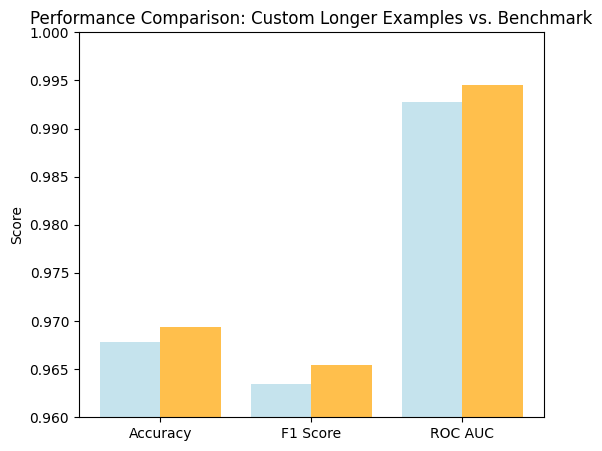

In [9]:
# Categories
metrics = ["Accuracy", "F1 Score", "ROC AUC"]

# Data for "Custom Longer Examples"
custom_longer_means = [0.9694, 0.9654, 0.9945]

# Data for "Benchmark"
benchmark_means = [0.9678, 0.9635, 0.9928]

# Bar width
bar_width = 0.4  
x = np.arange(len(metrics))  

# Create figure
plt.figure(figsize=(6, 5))
plt.bar(x - bar_width/2, benchmark_means, bar_width, label="Benchmark", color="lightblue", alpha=0.7)
plt.bar(x + bar_width/2, custom_longer_means, bar_width, label="Custom Longer Examples", color="orange", alpha=0.7)

# Labels and title
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Comparison: Custom Longer Examples vs. Benchmark")
plt.legend

# Zoom in by adjusting the y-axis limits to emphasize changes
plt.ylim(0.96, 1.0)


## **Truncating Inputs - something that didn't work...**
Initially, to improve the specific positive/negative examples and solve the full-stop focus issue, I wanted to use the following strategy:   
- Prompt openAI to generate longer examples - up to 5 sentences
- Create a function that would then randomly truncate the last sentence of each (either at a punctuation or after a token)    
- This would result in the last token being a random work instead of '.'
- Wanted something similar to mined negatives

However, I did try this, but the prompts always got cut off too short.  
I also tried to have each pos/neg pair be cut off at the same place.  
This was a bit difficult to achieve as there were still slight differences.   
So, I put it on pause for time being...    

Example:      
      "positive": "The patient's atorvastatin therapy was effective in achieving her cholesterol goals, reducing her LDL levels significantly.  The healthcare team discussed the importance of maintaining this treatment long-term. Regular follow-ups will ensure her lipid levels remain controlled.",      
      "negative": "The patient's therapy was effective in achieving her cholesterol goals, reducing her LDL levels significantly.  The healthcare team discussed the importance of maintaining this treatment long-term. Regular follow-ups will ensure her lipid levels"

## **Weight Decay and Learning Rate**

In [ ]:
# Define the data for each experiment as a list of dictionaries.
data = [
    {"Learning Rate": 0.003, "Decay": 0.1,   "CV Accuracy": 0.9758, "CV F1 Score": 0.9728, "CV ROC AUC": 0.9947},
    {"Learning Rate": 0.003, "Decay": 0.01,  "CV Accuracy": 0.9714, "CV F1 Score": 0.9677, "CV ROC AUC": 0.9933},
    {"Learning Rate": 0.003, "Decay": 0.05,  "CV Accuracy": 0.9670, "CV F1 Score": 0.9627, "CV ROC AUC": 0.9936},
    {"Learning Rate": 0.003, "Decay": 0.075, "CV Accuracy": 0.9717, "CV F1 Score": 0.9678, "CV ROC AUC": 0.9940},
    {"Learning Rate": 0.003, "Decay": 0.2,   "CV Accuracy": 0.9775, "CV F1 Score": 0.9746, "CV ROC AUC": 0.9948},
    {"Learning Rate": 0.003, "Decay": 0.5,   "CV Accuracy": 0.9800, "CV F1 Score": 0.9776, "CV ROC AUC": 0.9962},
    {"Learning Rate": 0.003, "Decay": 1.0,   "CV Accuracy": 0.9820, "CV F1 Score": 0.9797, "CV ROC AUC": 0.9963},
    # Note: For the next row the label "Lr 0.003 Lr 001 D001" is a bit ambiguous.
    # Here we interpret it as Learning Rate 0.003 with a Decay of 0.001.
    {"Learning Rate": 0.003, "Decay": 0.001, "CV Accuracy": 0.9675, "CV F1 Score": 0.9633, "CV ROC AUC": 0.9935},
    {"Learning Rate": 0.003, "Decay": 0.1,   "CV Accuracy": 0.9720, "CV F1 Score": 0.9689, "CV ROC AUC": 0.9951},
    {"Learning Rate": 0.01,  "Decay": 0.1,   "CV Accuracy": 0.9744, "CV F1 Score": 0.9712, "CV ROC AUC": 0.9947},
    {"Learning Rate": 0.01,  "Decay": 0.001, "CV Accuracy": 0.9658, "CV F1 Score": 0.9609, "CV ROC AUC": 0.9932},
    {"Learning Rate": 0.0005, "Decay": 0.1,   "CV Accuracy": 0.9764, "CV F1 Score": 0.9735, "CV ROC AUC": 0.9949},
    {"Learning Rate": 0.0005, "Decay": 0.5,   "CV Accuracy": 0.9814, "CV F1 Score": 0.9790, "CV ROC AUC": 0.9969},
    {"Learning Rate": 0.0005, "Decay": 1.0,   "CV Accuracy": 0.9820, "CV F1 Score": 0.9795, "CV ROC AUC": 0.9971},
    {"Learning Rate": 0.0006, "Decay": 1.0,   "CV Accuracy": 0.9786, "CV F1 Score": 0.9759, "CV ROC AUC": 0.9958},
    {"Learning Rate": 0.0007, "Decay": 1.0,   "CV Accuracy": 0.9811, "CV F1 Score": 0.9787, "CV ROC AUC": 0.9974},
    {"Learning Rate": 0.0008, "Decay": 1.0,   "CV Accuracy": 0.9836, "CV F1 Score": 0.9810, "CV ROC AUC": 0.9963},
    {"Learning Rate": 0.0009, "Decay": 1.0,   "CV Accuracy": 0.9811, "CV F1 Score": 0.9785, "CV ROC AUC": 0.9959}
]

# Create a DataFrame from the data list.
df = pd.DataFrame(data)

# Optionally, sort or reformat the DataFrame here if desired.

# Print the DataFrame as a formatted table.
print(df.to_string(index=False))

## **Unanswered Questions + Future Directions**

Due to time restraints, I wasn't able to complete all the experiments I had planned or wanted to :( - sorry!   
So, below I've listed some unanswered questions/future directions - either from the ideas that you sent me to try out, or other ideas I had along the way that I didn't get to try. 

### **Exploring 'Equivalent' Feature Difference Vectors**
As we know, these medical concepts can be represented by learned feature vectors.   
Past research on transformers have also shown that relationships between words (or concepts) can often be represented by subtracting/adding these vectors.   
For example:   

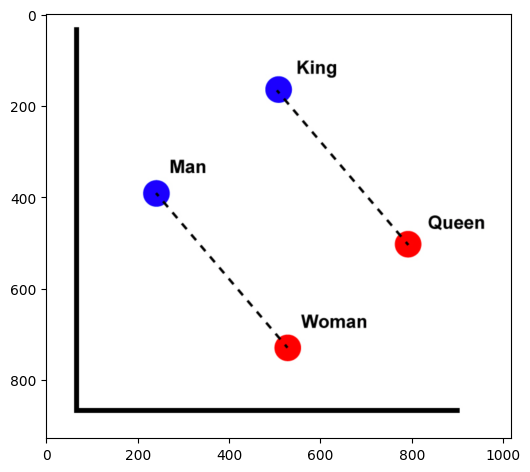

In [9]:
# Load and display an image
image_path = "feature_direction.png"  # Change this to your image file path
img = mpimg.imread(image_path)

plt.figure(figsize=(6,6))  # Adjust the figure size
plt.imshow(img)

### **Experiment Idea for Equivalent Feature Vectors**
I was curious about whether our probes could detect similar results like the image above.     
Whilst I know this doesn't directly relate to improving probe importance, I thought it might provide some useful info regarding interpretability.   
I am also just interested in seeing how this might go.    

**How would the experiment work?**
Instead of having using positive and negatives examples for each concept, we could pick two related concepts such as: high blood sugar and low blood sugar.   

Then, we would train a probe to differentiate between these two concepts.    

We could then do the same for another two related concepts that are related in the same way: e.g. high heart rate and low heart rate.   

Then, we can see if the learnt feature vector (that separates these two concepts) is similar or not.    

To get this feature vector, we can just use the direction of the logistic regression probe's weight vector.    

To compare these two directions, we can use a similarity measure like cosine similarity.    

If they are strongly aligned (close to 1 in cosine similarity), that indicates the “high vs. low” concept is being separated along a very similar dimension in the residual space for both blood sugar and heart rate. If they diverge, that suggests the model is using more specialized directions for each concept.

### **Artificial Positive Examples**
Artificial positive examples:    
Aappending positive examples to the general negative examples    
What's the best mix of new artificial positive examples and hard negative mining?    
Can we append positive examples to the mined (medicine-unrelated) negatives as well?    


## **Appendix**
Sorry for the slightly messy branch structure! I ran out of time a little to sort everything into a neat structure.   

### **Notes for scripts in 'experiments'**    
All the files starting in 'data' are modified 'data.py' files   
These are either for data length or data truncation

All the files starting with 'decay' are modified 'main.py' files for weight decay parameter testing    
All the files starting with 'lr' are modified 'main.py' files for learning rate and weight decay parameter testing    

All the files starting with 'period' are helper scripts that help remove a proportion of periods from the pos/neg examples   
All the files starting with 'period_train' are modified 'main.py' files for running the period experiments    

All the files starting with 'probe' are modified 'probe.py' files where I modified the training process   

All the file starting in 'prompt_length' are modified 'main.py' files for running the prompt length experiments   